In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df= pd.read_csv("creditcard.csv")

In [25]:
print(f"Dataset shape: { df.shape}")
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [26]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [27]:
print(df["Class"].value_counts())
counts= df["Class"].value_counts()
# 0 is Legitimate , 1 is fraudulent 

Class
0    284315
1       492
Name: count, dtype: int64


In [28]:
#Get percentage
perc_fraud= (counts[1]/ (counts[0]+counts[1])) *100
print(f"Genuine Transaction: {counts[0]}")
print(f"Fraudulent Transaction:{counts[1]} ({perc_fraud:.3f}%)")

Genuine Transaction: 284315
Fraudulent Transaction:492 (0.173%)


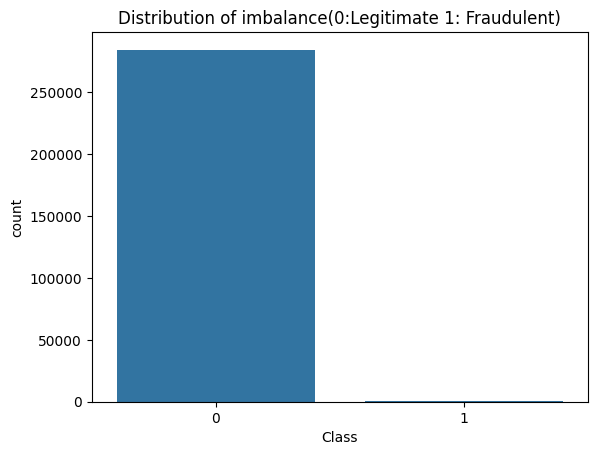

In [29]:
#PLOT the imbalance
sns.countplot(x="Class",data=df)
plt.title('Distribution of imbalance(0:Legitimate 1: Fraudulent)')
plt.show()

In [30]:
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


Feature Scaling

In [31]:
#Feature Scaling
from sklearn.preprocessing import RobustScaler
rob_scaler=RobustScaler()

In [32]:
#it compresses the "Amount" values into a smaller, standardized range so the XGBoost model doesn't get confused by very large or very small transactions.
df['scaled_amount']= rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time']= rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))


In [33]:
#Dropping the original column
df.drop(['Time', 'Amount'], axis=1, inplace=True)


In [34]:
scaled_amount=df['scaled_amount']
scaled_time=df['scaled_time']

In [35]:
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0,'scaled_amount', scaled_amount)
df.insert(1,'scaled_time', scaled_time)

df.head()

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## The "Baseline" XGBoost 

In [43]:
#Train test-split
from sklearn.model_selection import train_test_split
X= df.drop('Class', axis=1)
y=df['Class']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [44]:
#XG Boost Baseline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

model=XGBClassifier()
#XGBoost looks at the features in X_train (the V1-V28 PCA components) and tries to find patterns that lead to the labels in y_train (0 for Genuine, 1 for Fraud). 
# It builds a series of decision trees, where each new tree tries to correct the errors made by the previous ones.
model.fit(X_train, y_train)

#The model uses the patterns it learned during fit to guess the labels for this new data. y_pred is a list of 0s and 1s representing its predictions.
y_pred= model.predict(X_test)
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
#CF    N    P
#     TN    FP
#     FN    TP

Confusion Matrix
[[56852    12]
 [   20    78]]


Precision (86.6%): When I say it's fraud, I am right 86% of the time.

Recall (79.6%): I caught ~80% of all frauds, but 20% slipped through.

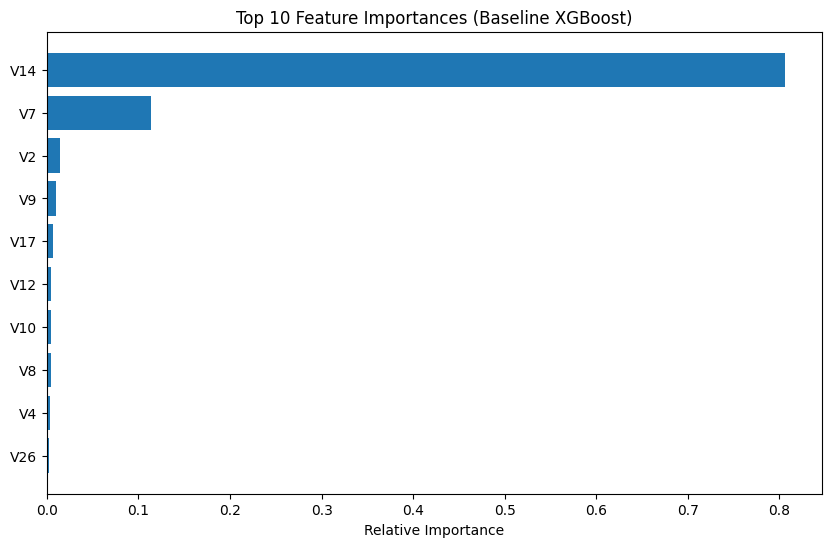

In [45]:
import matplotlib.pyplot as plt

# Get feature importance
importances = model.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10,6))
plt.title('Top 10 Feature Importances (Baseline XGBoost)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

## Handle Imbalance with SMOTE (The "Pro" Move)

In [49]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE only to the TRAINING data (never the test data)
sm = SMOTE(sampling_strategy='minority', random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f'Resampled dataset shape: {Counter(y_train_res)}')
model_smote = XGBClassifier()
model_smote.fit(X_train_res, y_train_res)
y_pred_smote = model_smote.predict(X_test)

print("SMOTE Confusion Matrix")
print(confusion_matrix(y_test, y_pred_smote))
print("\nSMOTE Classification Report")
print(classification_report(y_test, y_pred_smote))

Resampled dataset shape: Counter({0: 227451, 1: 227451})
SMOTE Confusion Matrix
[[56831    33]
 [   14    84]]

SMOTE Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.86      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



## Precision-Recall Curve

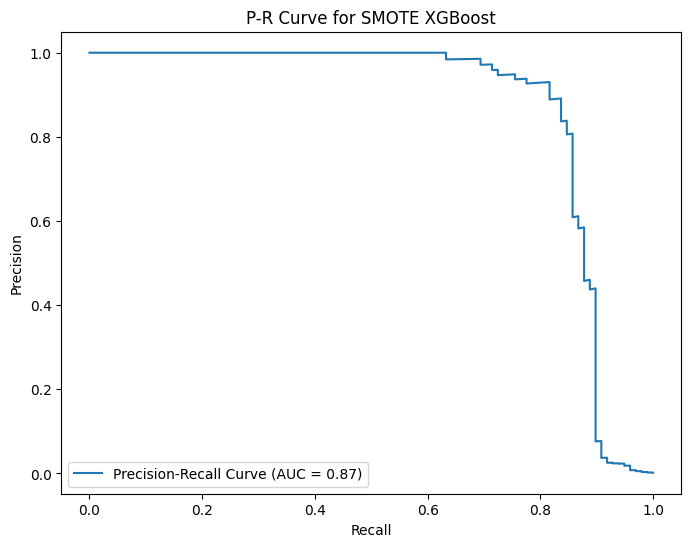

In [47]:
from sklearn.metrics import precision_recall_curve, auc

# Get probabilities
y_probs = model_smote.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'Precision-Recall Curve (AUC = {auc(recall, precision):.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('P-R Curve for SMOTE XGBoost')
plt.legend()
plt.show()

In [48]:
#Finding optimal threshold for best F1 score
f1_scores = 2 * (precision * recall) / (precision + recall)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Best Threshold for F1-Score: {best_threshold:.4f}")

Best Threshold for F1-Score: 0.9623


## RandomUnderSampler

In [50]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(sampling_strategy='majority', random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print(f'UnderSampled dataset shape: {Counter(y_train_rus)}')
model_rus = XGBClassifier()
model_rus.fit(X_train_rus, y_train_rus)
y_pred_rus = model_rus.predict(X_test)

print(" UnderSampling Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rus))
print("\nUnderSampling Classification Report")
print(classification_report(y_test, y_pred_rus))

UnderSampled dataset shape: Counter({0: 394, 1: 394})
 UnderSampling Confusion Matrix
[[54255  2609]
 [    8    90]]

UnderSampling Classification Report
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     56864
           1       0.03      0.92      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.95      0.97     56962



## SMOTE model. It provides a significant boost in catching fraud while keeping customer friction (False Positives) very low.